# Dubai Rental Market Trends and Price Prediction
## Analyzing 16 years of rental data to uncover trends and build a price prediction model
**Data Source:** Dubai Land Department Transaction Data  
**Tools:** Python, Pandas, Matplotlib, scikit-learn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("Transactions.csv")

# Filter only rental transactions
rentals = df[df['rent_value'] > 0].copy()
rentals = rentals[['instance_date', 'area_name_en', 'property_type_en', 'rooms_en', 'rent_value', 'procedure_area']].dropna(subset=['rent_value'])

# Convert date column
rentals['instance_date'] = pd.to_datetime(rentals['instance_date'], dayfirst=True)
rentals['year'] = rentals['instance_date'].dt.year

print(f"Total rental transactions: {len(rentals):,}")
print(f"Date range: {rentals['instance_date'].min()} to {rentals['instance_date'].max()}")
print(f"Unique areas: {rentals['area_name_en'].nunique()}")

Total rental transactions: 34,299
Date range: 2007-02-12 00:00:00 to 2023-03-16 00:00:00
Unique areas: 103


In [4]:
# Average rent per year
yearly_trend = rentals.groupby('year')['rent_value'].mean().reset_index()
yearly_trend.columns = ['year', 'avg_rent']

print(yearly_trend)

      year      avg_rent
0   2007.0  1.131651e+06
1   2008.0  1.769870e+06
2   2009.0  1.131514e+06
3   2010.0  1.377725e+06
4   2011.0  1.619375e+06
5   2012.0  1.446011e+06
6   2013.0  1.473348e+06
7   2014.0  1.522424e+06
8   2015.0  1.328864e+06
9   2016.0  1.549956e+06
10  2017.0  1.338603e+06
11  2018.0  1.376132e+06
12  2019.0  1.680616e+06
13  2020.0  1.926908e+06
14  2021.0  1.690241e+06
15  2022.0  1.748067e+06
16  2023.0  2.142893e+06


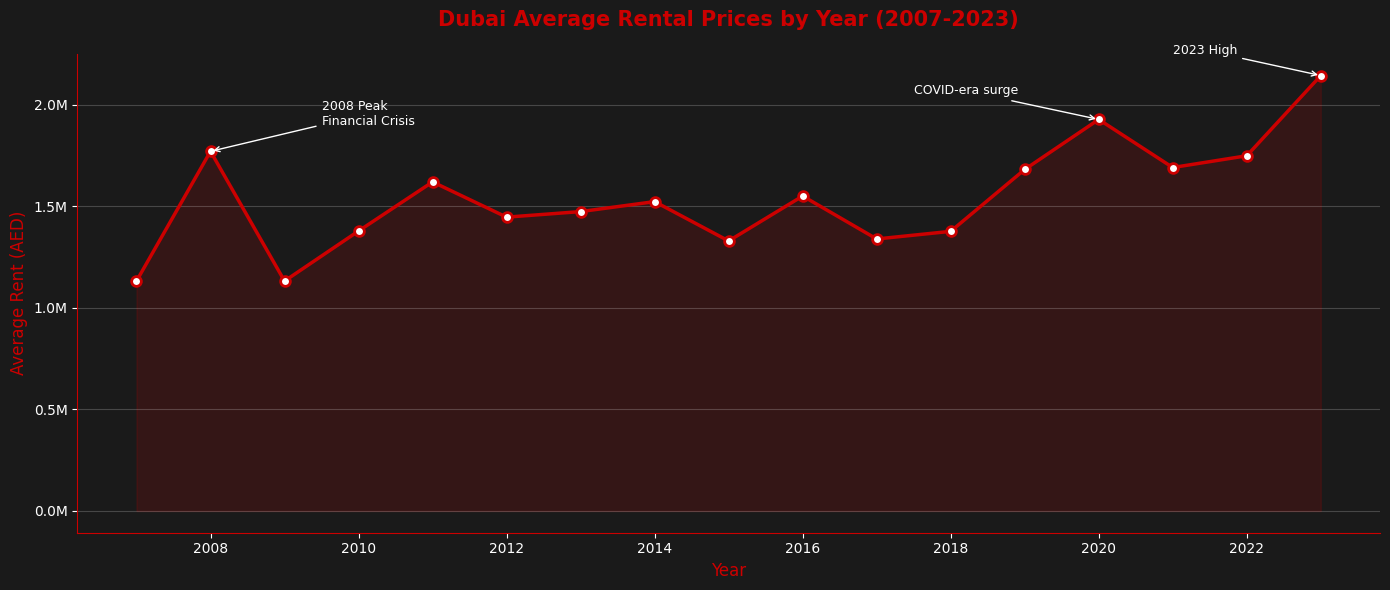

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(yearly_trend['year'], yearly_trend['avg_rent'], 
        color='#CC0000', linewidth=2.5, marker='o', markersize=7, markerfacecolor='white', markeredgewidth=2)

ax.fill_between(yearly_trend['year'], yearly_trend['avg_rent'], alpha=0.15, color='#CC0000')

ax.annotate('2008 Peak\nFinancial Crisis', xy=(2008, 1769870), xytext=(2009.5, 1900000),
            arrowprops=dict(arrowstyle='->', color='white'), color='white', fontsize=9)
ax.annotate('COVID-era surge', xy=(2020, 1926908), xytext=(2017.5, 2050000),
            arrowprops=dict(arrowstyle='->', color='white'), color='white', fontsize=9)
ax.annotate('2023 High', xy=(2023, 2142893), xytext=(2021, 2250000),
            arrowprops=dict(arrowstyle='->', color='white'), color='white', fontsize=9)

ax.set_facecolor('#1a1a1a')
fig.patch.set_facecolor('#1a1a1a')
ax.set_title('Dubai Average Rental Prices by Year (2007-2023)', 
             fontsize=15, fontweight='bold', color='#CC0000', pad=20)
ax.set_xlabel('Year', fontsize=12, color='#CC0000')
ax.set_ylabel('Average Rent (AED)', fontsize=12, color='#CC0000')
ax.tick_params(colors='white')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.spines['bottom'].set_color('#CC0000')
ax.spines['left'].set_color('#CC0000')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2, color='white')

plt.tight_layout()
plt.savefig('rental_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Training the model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

model_data = rentals[['area_name_en', 'property_type_en', 'rooms_en', 'procedure_area', 'year', 'rent_value']].dropna()

le_area = LabelEncoder()
le_type = LabelEncoder()
le_rooms = LabelEncoder()

model_data = model_data.copy()
model_data['area_encoded'] = le_area.fit_transform(model_data['area_name_en'])
model_data['type_encoded'] = le_type.fit_transform(model_data['property_type_en'])
model_data['rooms_encoded'] = le_rooms.fit_transform(model_data['rooms_en'])

X = model_data[['area_encoded', 'type_encoded', 'rooms_encoded', 'procedure_area', 'year']]
y = model_data['rent_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Here we are training the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluation on the test set
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: AED {mae:,.0f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error: AED 318,476
R² Score: 0.699


# Feature importance

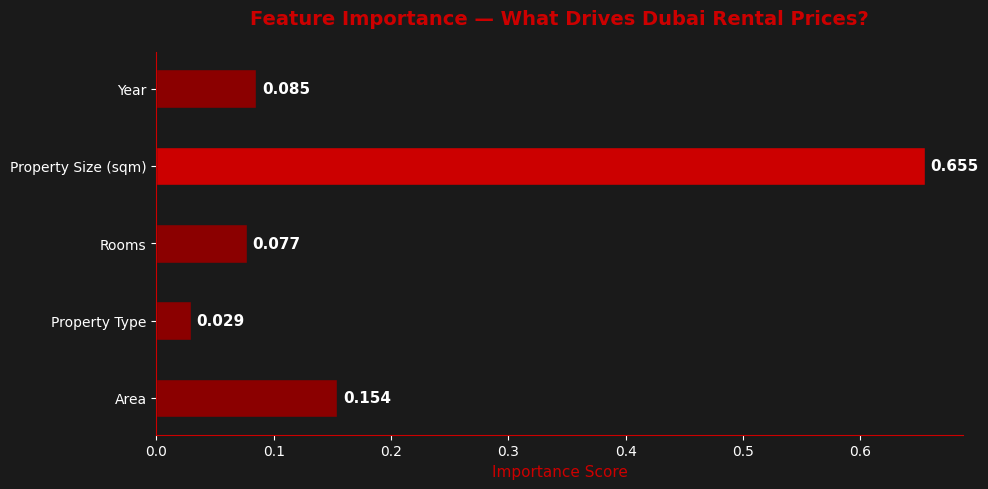

In [ ]:

features = ['Area', 'Property Type', 'Rooms', 'Property Size (sqm)', 'Year']
importances = model.feature_importances_

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#CC0000' if i == importances.argmax() else '#8B0000' for i in range(len(importances))]
bars = ax.barh(features, importances, color=colors, edgecolor='#1a1a1a', height=0.5)

for bar, val in zip(bars, importances):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_facecolor('#1a1a1a')
fig.patch.set_facecolor('#1a1a1a')
ax.set_title('Feature Importance — What Drives Dubai Rental Prices?',
             fontsize=14, fontweight='bold', color='#CC0000', pad=20)
ax.set_xlabel('Importance Score', fontsize=11, color='#CC0000')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CC0000')
ax.spines['bottom'].set_color('#CC0000')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings for this project

- Dubai rental prices hit an all time high in 2023 at an average of AED 2.14M, surpassing even the 2008 pre-crisis peak
- Prices dropped sharply after the 2008 financial crisis but have been climbing steadily since 2019 with no signs of slowing
- Property size is the strongest predictor of rental price with an importance score of 0.655, outweighing both location and room count
- Area still accounts for 15.4% of rental price variation, meaning neighbourhood choice does matter but size dominates
- The Random Forest model explains 70% of rental price variance with a mean absolute error of AED 318,476

## Model Performance according to the datasets
- Mean Absolute Error: AED 318,476
- R² Score: 0.699